#**Trabajo N°1 — Fundamentos de Ciencia de Datos**
**Proyecto 3 — Predicción del valor de propiedades**

**Hito 1 — Análisis exploratorio de datos**

El objetivo de este notebook es comprender y caracterizar los datos antes del modelamiento, identificando patrones y problemas que permitan formular una hipótesis de investigación coherente con la predicción de 2017 a partir de 2016.


**Problema del Proyecto**

El proyecto solicita utilizar las ventas de propiedades observadas durante **2016** como información de entrenamiento para un modelo posterior y evaluar ese modelo con propiedades de **2017**. En este Hito 1 no se entrenará ningún modelo: primero se debe comprender el conjunto de datos, revisar su calidad y explorar relaciones descriptivas.

**Pregunta inicial de trabajo**

¿Qué características presentan los datos de propiedades de Melbourne y qué patrones observados permiten plantear una hipótesis razonable para predecir los precios de 2017 utilizando información de 2016?

**Paso 1 - Importación de librerías**


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

**Paso 2 - Carga del dataset y revisión general**


In [26]:
DATA_CANDIDATES = [
    Path("/content/sample_data/housing_data.csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
DATA_AVAILABLE = DATA_PATH is not None

if DATA_AVAILABLE:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset cargado desde: {DATA_PATH}")
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
    print("\nPrimeras filas:")
    print(df.head().to_string())
    print("\nNombres de columnas:")
    print(df.columns.tolist())
    print("\nTipos de datos:")
    print(df.dtypes.to_string())
    print("\nInformación general:")
    df.info()
else:
    df = pd.DataFrame()
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES: no se encontró housing_data.csv.")

Dataset cargado desde: /content/sample_data/housing_data.csv
Filas: 13,580 | Columnas: 21

Primeras filas:
       Suburb           Address  Rooms Type      Price Method SellerG       Date  Distance  Postcode  Bedroom2  Bathroom  Car  Landsize  BuildingArea  YearBuilt CouncilArea  Lattitude  Longtitude             Regionname  Propertycount
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin  3/12/2016       2.5    3067.0       2.0       1.0  1.0     202.0           NaN        NaN       Yarra   -37.7996    144.9984  Northern Metropolitan         4019.0
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin  4/02/2016       2.5    3067.0       2.0       1.0  0.0     156.0          79.0     1900.0       Yarra   -37.8079    144.9934  Northern Metropolitan         4019.0
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin  4/03/2017       2.5    3067.0       3.0       2.0  0.0     134.0         150.0     1900.0       Yarra   -37.8093    144.

In [27]:
#Renombramos las columnas:

df.rename(columns={
    'Suburb': 'Barrio',
    'Rooms': 'Habitaciones',
    'Address': 'Dirección',
    'Price': 'Precio',
    'Type': 'Tipo',
    'Method': 'Método',
    'SellerG': 'Vendedor',
    'Date': 'Fecha',
    'Distance': 'Distancia',
    'Bedroom2': 'Habitaciones2',
    'Bathroom': 'Baños',
    'Car': 'Automóviles',
    'Landsize': 'Tamaño de tierra',
    'BuildingArea': 'Tamaño de construcción',
    'YearBuilt': 'Año de construcción',
    'CouncilArea': 'Comuna',
    'Lattitude': 'Latitud',
    'Longtitude': 'Longitud',
    'Regionname': 'Región',
    'Propertycount': 'Cantidad de propiedades'
}, inplace=True)
# If you want to rename other columns, please check the available column names in df.info()
# df.rename(columns={
#    'zip_code': 'Código postal',
#    'title': 'Título'
# }, inplace=True)
df.head()

,Barrio,Dirección,Habitaciones,Tipo,Precio,Método,Vendedor,Fecha,Distancia,Postcode,Habitaciones2,Baños,Automóviles,Tamaño de tierra,Tamaño de construcción,Año de construcción,Comuna,Latitud,Longitud,Región,Cantidad de propiedades
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [54]:
# Reemplazar los valores de la columna 'Tipo' con descripciones más claras

df['Tipo'] = df['Tipo'].replace({
    'h': 'casa',
    't': 'casapareada',
    'u': 'duplex'
})

# Mostrar la distribución de los nuevos valores para verificar el cambio
display(df['Tipo'].value_counts())

# Mostrar las primeras filas del DataFrame para ver el efecto
df.head()

,count
Tipo,
casa,9449
duplex,3017
casapareada,1114


,Barrio,Dirección,Habitaciones,Tipo,Precio,Método,Vendedor,Fecha,Distancia,Postcode,Habitaciones2,Baños,Automóviles,Tamaño de tierra,Tamaño de construcción,Año de construcción,Comuna,Latitud,Longitud,Región,Cantidad de propiedades,Year
0,Abbotsford,85 Turner St,2,casa,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016
1,Abbotsford,25 Bloomburg St,2,casa,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016
2,Abbotsford,5 Charles St,3,casa,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017
3,Abbotsford,40 Federation La,3,casa,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017
4,Abbotsford,55a Park St,4,casa,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016


In [61]:
# Reemplazar los valores de la columna 'Método' con descripciones más claras y nuevas traducciones

df['Método'] = df['Método'].replace({
    'S': 'Vendida',
    'SP': 'Vendida con anterioridad',
    'PI': 'Propiedad pasada en',
    'VB': 'Oferta del vendedor',
    'SA': 'Rematada'
})

# Mostrar la distribución de los nuevos valores para verificar el cambio
print('Valores únicos en la columna "Método" después de la sustitución (nuevos términos):')
display(df['Método'].value_counts())

# Mostrar las primeras filas del DataFrame para ver el efecto
print('\nPrimeras filas del DataFrame con el Método actualizado (nuevos términos):')
display(df.head())

Valores únicos en la columna "Método" después de la sustitución (nuevos términos):


,count
Método,
Vendida,9022
Vendida con anterioridad,1703
Propiedad pasada en,1564
Oferta del vendedor,1199
Rematada,92



Primeras filas del DataFrame con el Método actualizado (nuevos términos):


,Barrio,Dirección,Habitaciones,Tipo,Precio,Método,Vendedor,Fecha,Distancia,Postcode,Habitaciones2,Baños,Automóviles,Tamaño de tierra,Tamaño de construcción,Año de construcción,Comuna,Latitud,Longitud,Región,Cantidad de propiedades,Year
0,Abbotsford,85 Turner St,2,casa,1480000.0,Vendida,Biggin,2016-12-03,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016
1,Abbotsford,25 Bloomburg St,2,casa,1035000.0,Vendida,Biggin,2016-02-04,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016
2,Abbotsford,5 Charles St,3,casa,1465000.0,Vendida con anterioridad,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017
3,Abbotsford,40 Federation La,3,casa,850000.0,Propiedad pasada en,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017
4,Abbotsford,55a Park St,4,casa,1600000.0,Oferta del vendedor,Nelson,2016-06-04,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016


**Paso 3 - Descripción del conjunto de datos**

Una fila representa una observación de una propiedad registrada en el conjunto de datos. La variable objetivo del proyecto es **`Price`**.

**- Variables estructurales a revisar:** `Rooms`, `Bedroom2`, `Bathroom`, `Car`, `Landsize`, `BuildingArea`, `YearBuilt`, `Type`.

**- Variables espaciales:** `Suburb`, `Distance`, `CouncilArea`, `Regionname`, `Lattitude`, `Longtitude`, `Propertycount`.

**- Variables comerciales/contextuales:** `Method`, `SellerG`, `Date`.



In [62]:
EXPECTED_COLUMNS = {
    "Barrio", "Habitaciones", "Dirección", "Precio", "Tipo", "Método", "Vendedor", "Fecha",
    "Distancia", "Habitaciones2", "Baños", "Automóviles", "Tamaño de tierra", "Tamaño de construcción",
    "Año de construcción", "Comuna", "Latitud", "Longitud", "Región",
    "Cantidad de propiedades"
}

if DATA_AVAILABLE:
    missing_columns = sorted(EXPECTED_COLUMNS.difference(df.columns))
    if missing_columns:
        raise ValueError(f"Faltan columnas esperadas en el dataset: {missing_columns}")

    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

    print(f"Filas: {df.shape[0]:,}")
    print(f"Columnas: {df.shape[1]}")
    print(f"Variables numéricas ({len(numeric_columns)}): {numeric_columns}")
    print(f"Variables no numéricas ({len(categorical_columns)}): {categorical_columns}")
else:
    print("NO REVALIDADA DESDE EL CSV.")

Filas: 13,580
Columnas: 22
Variables numéricas (14): ['Habitaciones', 'Precio', 'Distancia', 'Postcode', 'Habitaciones2', 'Baños', 'Automóviles', 'Tamaño de tierra', 'Tamaño de construcción', 'Año de construcción', 'Latitud', 'Longitud', 'Cantidad de propiedades', 'Year']
Variables no numéricas (8): ['Barrio', 'Dirección', 'Tipo', 'Método', 'Vendedor', 'Fecha', 'Comuna', 'Región']


**Paso 6 - Calidad de los Datos**

- Corrección del dato `Date`.
- Validación de datos vacíos.
- Validación de datos duplicados.
- Validación de rangos posiblemente problemáticos.
- `Method` y el concepto de venta.



**6.1. Corrección de `Date`:**

`Date` se interpreta como fecha con día primero. A partir de ella se crea `Year`, que permite separar 2016 y 2017.

**Interpretación exploratoria:** la variable `Year` será la base para comparar 2016 y 2017 una vez ejecutado el notebook con los datos reales.

In [63]:
if DATA_AVAILABLE:
    date_original_non_null = df["Fecha"].notna().sum()
    df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors="coerce")
    date_parsed_non_null = df["Fecha"].notna().sum()
    df["Year"] = df["Fecha"].dt.year

    print("Registros por año:")
    print(df["Year"].value_counts(dropna=False).sort_index().to_string())
    print(f"Fechas no nulas antes de convertir: {date_original_non_null}")
    print(f"Fechas válidas después de convertir: {date_parsed_non_null}")
    print(f"Rango temporal: {df['Fecha'].min()} a {df['Fecha'].max()}")
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

Registros por año:
Year
2016    6336
2017    7244
Fechas no nulas antes de convertir: 13580
Fechas válidas después de convertir: 13580
Rango temporal: 2016-01-28 00:00:00 a 2017-09-23 00:00:00


**6.2. Validación de datos vacíos o faltantes:**

**Interpretación exploratoria:** una fracción alta de datos ausentes puede reducir la información utilizable de una variable y debe considerarse antes de modelar. En este caso, encontramos que `BuildingArea`, `YearBuilt` y `CouncilArea`, en suma componen el 100% de campos vacíos, por lo que no se usarán estas variables para el modelo.


In [64]:
if DATA_AVAILABLE:
    missing_table = pd.DataFrame({
        "Cantidad": df.isna().sum(),
        "Porcentaje (%)": (df.isna().sum() / len(df) * 100).round(2)
    }).sort_values(["Porcentaje (%)", "Cantidad"], ascending=False)

    print(missing_table.to_string())
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

                         Cantidad  Porcentaje (%)
Tamaño de construcción       6450           47.50
Año de construcción          5375           39.58
Comuna                       1369           10.08
Automóviles                    62            0.46
Barrio                          0            0.00
Dirección                       0            0.00
Habitaciones                    0            0.00
Tipo                            0            0.00
Precio                          0            0.00
Método                          0            0.00
Vendedor                        0            0.00
Fecha                           0            0.00
Distancia                       0            0.00
Postcode                        0            0.00
Habitaciones2                   0            0.00
Baños                           0            0.00
Tamaño de tierra                0            0.00
Latitud                         0            0.00
Longitud                        0            0.00


**6.3. Validación de datos duplicados:**

**Interpretación exploratoria:** su existencia debe revisarse antes de decidir si representan registros repetidos o eventos legítimos, sin embargo en el caso, no se detectaron filas completamente duplicadas.


In [65]:
if DATA_AVAILABLE:
    duplicate_count = int(df.duplicated().sum())
    print(f"Filas completamente duplicadas: {duplicate_count}")
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

Filas completamente duplicadas: 0


**6.4. Validación de rangos posiblemente problemáticos:**

**Interpretación exploratoria:** valores cero, negativos o años futuros deben investigarse según el significado de cada variable; no se borran en silencio.


In [66]:
RANGE_COLUMNS = ["Precio", "Habitaciones", "Tamaño de tierra", "Tamaño de construcción", "Año de construcción", "Distancia"]

if DATA_AVAILABLE:
    rows = []
    current_year = pd.Timestamp.today().year

    for col in RANGE_COLUMNS:
        s = pd.to_numeric(df[col], errors="coerce")
        row = {
            "Variable": col,
            "Mínimo": s.min(),
            "Máximo": s.max(),
            "Nulos": int(s.isna().sum()),
            "Valores < 0": int((s < 0).sum()),
            "Valores = 0": int((s == 0).sum()),
        }
        if col == "Año de construcción":
            row["Años > año actual"] = int((s > current_year).sum())
        rows.append(row)

    range_review = pd.DataFrame(rows)
    print(range_review.to_string(index=False))
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

              Variable  Mínimo    Máximo  Nulos  Valores < 0  Valores = 0  Años > año actual
                Precio 85000.0 9000000.0      0            0            0                NaN
          Habitaciones     1.0      10.0      0            0            0                NaN
      Tamaño de tierra     0.0  433014.0      0            0         1939                NaN
Tamaño de construcción     0.0   44515.0   6450            0           17                NaN
   Año de construcción  1196.0    2018.0   5375            0            0                0.0
             Distancia     0.0      48.1      0            0            6                NaN


**6.5. `Method` y el concepto de venta:**

**Interpretación exploratoria:** `Method` debe revisarse antes de definir operativamente qué observaciones constituyen una "venta" para el proyecto.

In [67]:
if DATA_AVAILABLE:
    method_counts = df["Método"].value_counts(dropna=False)
    method_props = df["Método"].value_counts(dropna=False, normalize=True).mul(100).round(2)

    method_table = pd.DataFrame({
        "Cantidad": method_counts,
        "Porcentaje (%)": method_props
    })
    print(method_table.to_string())
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

                          Cantidad  Porcentaje (%)
Método                                            
Vendida                       9022           66.44
Vendida con anterioridad      1703           12.54
Propiedad pasada en           1564           11.52
Oferta del vendedor           1199            8.83
Rematada                        92            0.68


**Paso 7 - Análisis Exploratorio de la Data**

- Distribución de `Precio`.
- Distribución de `Tipo`.
- Distribución de `Metodo`.
- Relación `Precio` vs `Habitaciones`.
- Relación `Precio` vs `Tipo`.
- Relación `Precio` vs `Distancia`.



**7.1. Distribución de `Precio`:**

**Interpretación exploratoria:** deben compararse media y mediana, forma del histograma e IQR para describir asimetría y valores extremos. Si media y mediana difieren de forma visible, la mediana puede ser una referencia más robusta del precio típico.

count                  1.358000e+04
mínimo                 8.500000e+04
máximo                 9.000000e+06
media                  1.075684e+06
mediana                9.030000e+05
desviación estándar    6.393107e+05
varianza               4.087182e+11
Q1                     6.500000e+05
Q3                     1.330000e+06
IQR                    6.800000e+05


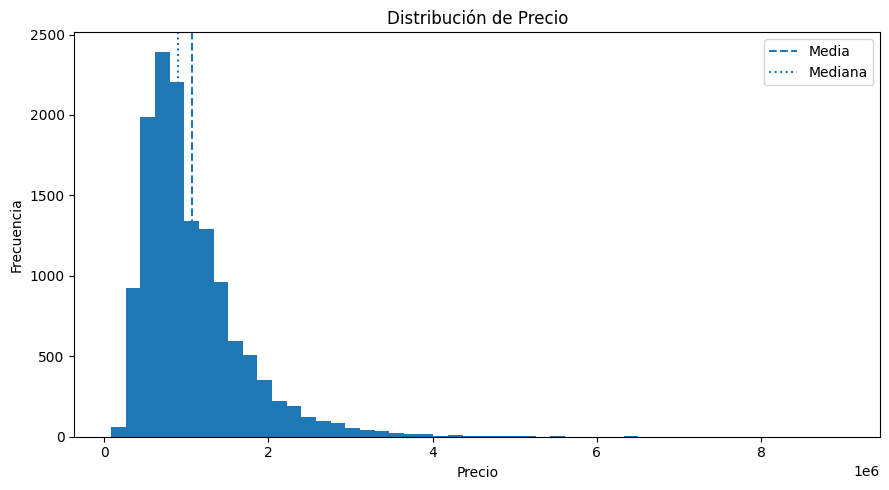

In [68]:
if DATA_AVAILABLE:
    price = pd.to_numeric(df["Precio"], errors="coerce").dropna()

    q1 = price.quantile(0.25)
    q3 = price.quantile(0.75)
    price_stats = pd.Series({
        "count": price.count(),
        "mínimo": price.min(),
        "máximo": price.max(),
        "media": price.mean(),
        "mediana": price.median(),
        "desviación estándar": price.std(),
        "varianza": price.var(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
    })

    print(price_stats.to_string())

    plt.figure(figsize=(9, 5))
    plt.hist(price, bins=50)
    plt.axvline(price.mean(), linestyle="--", label="Media")
    plt.axvline(price.median(), linestyle=":", label="Mediana")
    plt.title("Distribución de Precio")
    plt.xlabel("Precio")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

**7.2. Distribución de `Type`:**

**Interpretación exploratoria:** una composición muy desigual entre categorías debe considerarse al comparar precios y, posteriormente, al evaluar el modelo.

             Cantidad  Porcentaje (%)
Tipo                                 
casa             9449           69.58
duplex           3017           22.22
casapareada      1114            8.20


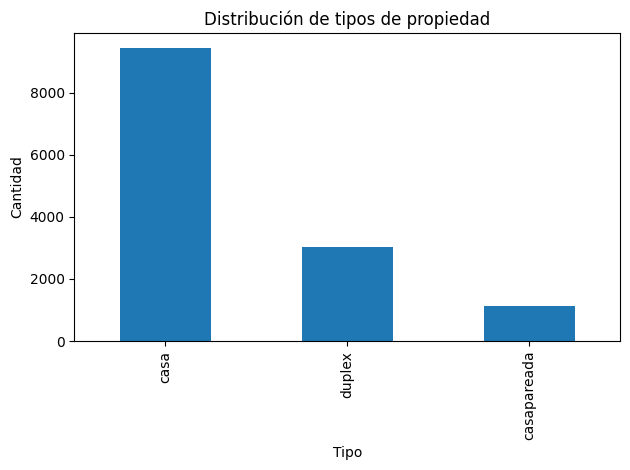

In [69]:
if DATA_AVAILABLE:
    type_counts = df["Tipo"].value_counts(dropna=False)
    type_props = df["Tipo"].value_counts(dropna=False, normalize=True).mul(100).round(2)
    type_table = pd.DataFrame({"Cantidad": type_counts, "Porcentaje (%)": type_props})
    print(type_table.to_string())

    type_counts.plot(kind="bar")
    plt.title("Distribución de tipos de propiedad")
    plt.xlabel("Tipo")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

**7.3. Distribución de `Method`:**

**Interpretación exploratoria:** esta distribución ayuda a verificar si el universo observado mezcla distintos mecanismos de transacción.

                          Cantidad  Porcentaje (%)
Método                                            
Vendida                       9022           66.44
Vendida con anterioridad      1703           12.54
Propiedad pasada en           1564           11.52
Oferta del vendedor           1199            8.83
Rematada                        92            0.68


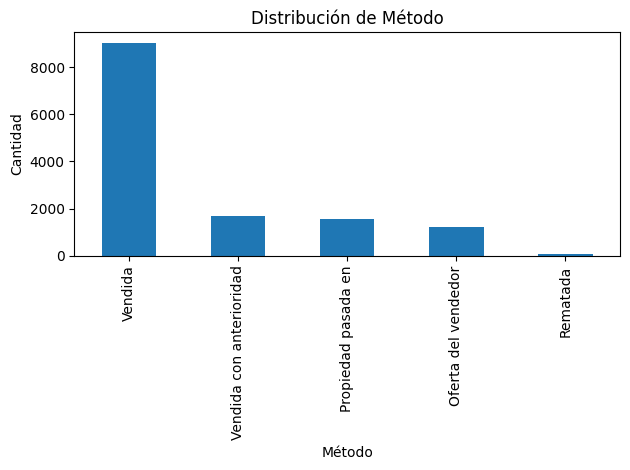

In [70]:
if DATA_AVAILABLE:
    method_counts = df["Método"].value_counts(dropna=False)
    method_props = df["Método"].value_counts(dropna=False, normalize=True).mul(100).round(2)
    print(pd.DataFrame({"Cantidad": method_counts, "Porcentaje (%)": method_props}).to_string())

    method_counts.plot(kind="bar")
    plt.title("Distribución de Método")
    plt.xlabel("Método")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

**7.4. Relación `Price` vs `Room`:**

**Interpretación exploratoria:** una relación consistente sugeriría asociación entre tamaño estructural aproximado y precio.

Correlación Habitaciones-Precio: 0.4966

Mediana de Precio por Habitaciones:
Habitaciones
1      385000.0
2      690000.0
3      950000.0
4     1285000.0
5     1660000.0
6     1800000.0
7     1496000.0
8     1515000.0
10     900000.0


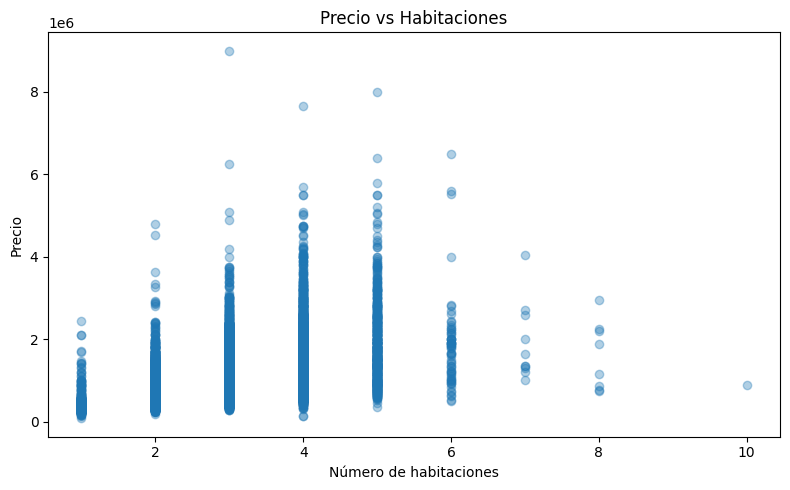

In [71]:
if DATA_AVAILABLE:
    rooms_price = df[["Habitaciones", "Precio"]].apply(pd.to_numeric, errors="coerce").dropna()
    corr_rooms = rooms_price["Habitaciones"].corr(rooms_price["Precio"])
    median_by_rooms = rooms_price.groupby("Habitaciones")["Precio"].median().sort_index()

    print(f"Correlación Habitaciones-Precio: {corr_rooms:.4f}")
    print("\nMediana de Precio por Habitaciones:")
    print(median_by_rooms.to_string())

    plt.figure(figsize=(8, 5))
    plt.scatter(rooms_price["Habitaciones"], rooms_price["Precio"], alpha=0.35)
    plt.title("Precio vs Habitaciones")
    plt.xlabel("Número de habitaciones")
    plt.ylabel("Precio")
    plt.tight_layout()
    plt.show()
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

**7.5. Relación `Price` vs `Type`:**

**Interpretación exploratoria:** diferencias persistentes entre cajas y medianas pueden indicar que `Type` contiene información útil asociada a `Price`.

             count     median
Tipo                         
casa          9449  1080000.0
casapareada   1114   846750.0
duplex        3017   560000.0


<Figure size 900x500 with 0 Axes>

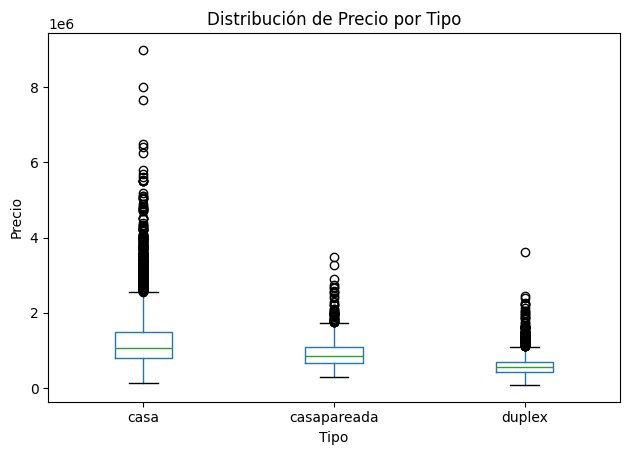

In [72]:
if DATA_AVAILABLE:
    type_price = df[["Tipo", "Precio"]].copy()
    type_price["Precio"] = pd.to_numeric(type_price["Precio"], errors="coerce")
    type_price = type_price.dropna()

    summary_type_price = type_price.groupby("Tipo")["Precio"].agg(["count", "median"]).sort_values("median", ascending=False)
    print(summary_type_price.to_string())

    plt.figure(figsize=(9, 5))
    type_price.boxplot(column="Precio", by="Tipo", grid=False)
    plt.title("Distribución de Precio por Tipo")
    plt.suptitle("")
    plt.xlabel("Tipo")
    plt.ylabel("Precio")
    plt.tight_layout()
    plt.show()
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

**7.6. Relación de `Price` vs `Distance`:**

**Interpretación exploratoria:** el signo y magnitud de la correlación ayudan a evaluar si la variable locacional merece atención en el modelamiento posterior.


Correlación Distancia-Precio: -0.1625


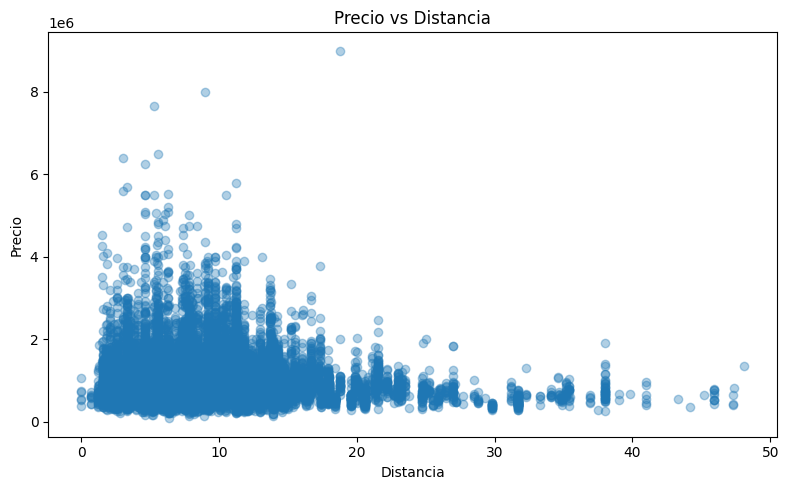

In [73]:
if DATA_AVAILABLE:
    distance_price = df[["Distancia", "Precio"]].apply(pd.to_numeric, errors="coerce").dropna()
    corr_distance = distance_price["Distancia"].corr(distance_price["Precio"])
    print(f"Correlación Distancia-Precio: {corr_distance:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(distance_price["Distancia"], distance_price["Precio"], alpha=0.35)
    plt.title("Precio vs Distancia")
    plt.xlabel("Distancia")
    plt.ylabel("Precio")
    plt.tight_layout()
    plt.show()
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

**8. Comparaciòn `Year` (2016 vs 2017):**


**Pregunta de esta sección:** ¿2017 presenta exactamente la misma composición que los datos disponibles en 2016?

**Interpretación exploratoria:** cualquier diferencia descriptiva entre años es relevante para comprender el desafío de evaluar en 2017 un modelo construido con 2016.


Resumen comparativo:
                       2016      2017
Registros            6336.0    7244.0
Mediana Precio     900000.0  910000.0
Mediana Distancia       8.8      10.5
Barrio distintos      142.0     313.0

Composición de Tipo por año (%):
Year          2016   2017
Tipo                     
casa         65.80  72.89
casapareada   8.46   7.98
duplex       25.74  19.13

Barrio presentes en 2017 y ausentes en 2016: 172
['Albanvale', 'Altona Meadows', 'Ardeer', 'Aspendale', 'Aspendale Gardens', 'Attwood', 'Bacchus Marsh', 'Bayswater', 'Bayswater North', 'Beaconsfield', 'Beaconsfield Upper', 'Beaumaris', 'Berwick', 'Black Rock', 'Blackburn', 'Blackburn North', 'Blackburn South', 'Bonbeach', 'Boronia', 'Briar Hill', 'Broadmeadows', 'Brookfield', 'Bullengarook', 'Bundoora', 'Burnside', 'Burnside Heights', 'Burwood East', 'Cairnlea', 'Caroline Springs', 'Carrum'] ...
Categorías nuevas de Tipo en 2017 respecto de 2016: []
Categorías nuevas de Método en 2017 respecto de 2016: []


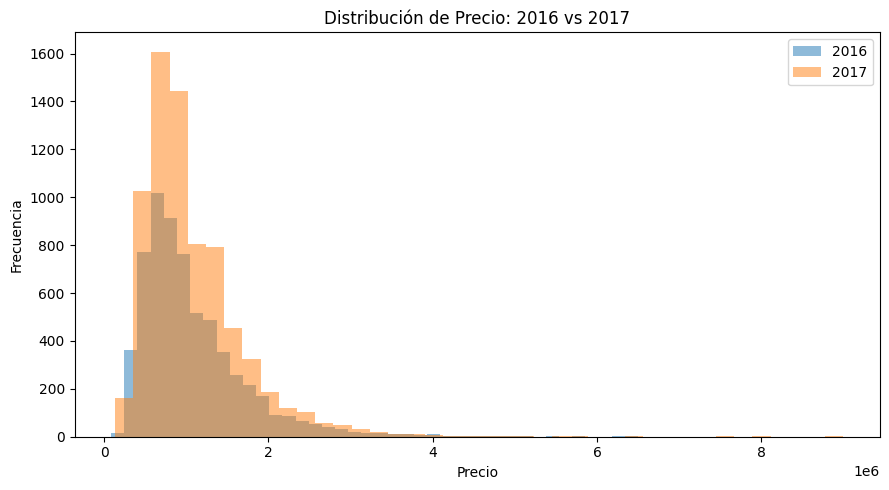

In [74]:
if DATA_AVAILABLE:
    df_2016 = df[df["Year"] == 2016].copy()
    df_2017 = df[df["Year"] == 2017].copy()

    comparison = pd.DataFrame({
        "2016": {
            "Registros": len(df_2016),
            "Mediana Precio": pd.to_numeric(df_2016["Precio"], errors="coerce").median(),
            "Mediana Distancia": pd.to_numeric(df_2016["Distancia"], errors="coerce").median(),
            "Barrio distintos": df_2016["Barrio"].nunique(dropna=True),
        },
        "2017": {
            "Registros": len(df_2017),
            "Mediana Precio": pd.to_numeric(df_2017["Precio"], errors="coerce").median(),
            "Mediana Distancia": pd.to_numeric(df_2017["Distancia"], errors="coerce").median(),
            "Barrio distintos": df_2017["Barrio"].nunique(dropna=True),
        }
    })
    print("Resumen comparativo:")
    print(comparison.to_string())

    print("\nComposición de Tipo por año (%):")
    type_year = pd.crosstab(df["Tipo"], df["Year"], normalize="columns").mul(100).round(2)
    print(type_year.to_string())

    suburbs_2016 = set(df_2016["Barrio"].dropna().unique())
    suburbs_2017 = set(df_2017["Barrio"].dropna().unique())
    new_suburbs_2017 = sorted(suburbs_2017 - suburbs_2016)

    print(f"\nBarrio presentes en 2017 y ausentes en 2016: {len(new_suburbs_2017)}")
    if len(new_suburbs_2017) <= 30:
        print(new_suburbs_2017)
    else:
        print(new_suburbs_2017[:30], "...")

    for col in ["Tipo", "Método"]:
        values_2016 = set(df_2016[col].dropna().unique())
        values_2017 = set(df_2017[col].dropna().unique())
        new_values = sorted(values_2017 - values_2016)
        print(f"Categorías nuevas de {col} en 2017 respecto de 2016: {new_values}")

    price_2016 = pd.to_numeric(df_2016["Precio"], errors="coerce").dropna()
    price_2017 = pd.to_numeric(df_2017["Precio"], errors="coerce").dropna()

    if len(price_2016) and len(price_2017):
        plt.figure(figsize=(9, 5))
        plt.hist(price_2016, bins=40, alpha=0.5, label="2016")
        plt.hist(price_2017, bins=40, alpha=0.5, label="2017")
        plt.title("Distribución de Precio: 2016 vs 2017")
        plt.xlabel("Precio")
        plt.ylabel("Frecuencia")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    df_2016 = pd.DataFrame()
    df_2017 = pd.DataFrame()
    new_suburbs_2017 = []
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

**9. Matriz de Correlación:**

**Interpretación exploratoria:** magnitudes altas pueden señalar variables descriptivamente relacionadas con el precio; una correlación alta entre dos explicativas, como `Rooms` y `Bedroom2`, puede sugerir redundancia.

In [76]:
def describe_correlation(r):
    if pd.isna(r):
        return "No calculable"
    magnitude = abs(r)
    if magnitude < 0.20:
        level = "muy débil"
    elif magnitude < 0.40:
        level = "débil"
    elif magnitude < 0.60:
        level = "moderada"
    elif magnitude < 0.80:
        level = "fuerte"
    else:
        level = "muy fuerte"
    direction = "positiva" if r > 0 else "negativa" if r < 0 else "nula"
    return f"{direction}, {level}"

if DATA_AVAILABLE:
    numeric_df = df.select_dtypes(include=[np.number])
    correlation_matrix = numeric_df.corr()

    print("Matriz de correlación numérica:")
    print(correlation_matrix.round(3).to_string())

    if "Price" in correlation_matrix.columns:
        price_correlations = (
            correlation_matrix["Price"]
            .drop(labels=["Price"], errors="ignore")
            .dropna()
            .sort_values(key=lambda s: s.abs(), ascending=False)
        )
        correlation_table = pd.DataFrame({
            "Variable": price_correlations.index,
            "Correlación con Price": price_correlations.values,
            "Interpretación exploratoria": [describe_correlation(r) for r in price_correlations.values],
        })
        print("\nCorrelaciones específicas con Price:")
        print(correlation_table.to_string(index=False))

        if {"Rooms", "Bedroom2"}.issubset(correlation_matrix.columns):
            print(f"\nCorrelación Rooms-Bedroom2: {correlation_matrix.loc['Rooms', 'Bedroom2']:.4f}")
else:
    print("NO VERIFICABLE CON LOS DATOS DISPONIBLES.")

Matriz de correlación numérica:
                         Habitaciones  Precio  Distancia  Postcode  Habitaciones2  Baños  Automóviles  Tamaño de tierra  Tamaño de construcción  Año de construcción  Latitud  Longitud  Cantidad de propiedades   Year
Habitaciones                    1.000   0.497      0.294     0.055          0.944  0.593        0.408             0.026                   0.124               -0.065    0.016     0.101                   -0.082  0.092
Precio                          0.497   1.000     -0.163     0.108          0.476  0.467        0.239             0.038                   0.091               -0.324   -0.213     0.204                   -0.042  0.004
Distancia                       0.294  -0.163      1.000     0.432          0.296  0.127        0.263             0.025                   0.099                0.246   -0.131     0.239                   -0.055  0.250
Postcode                        0.055   0.108      0.432     1.000          0.061  0.114        0.050   

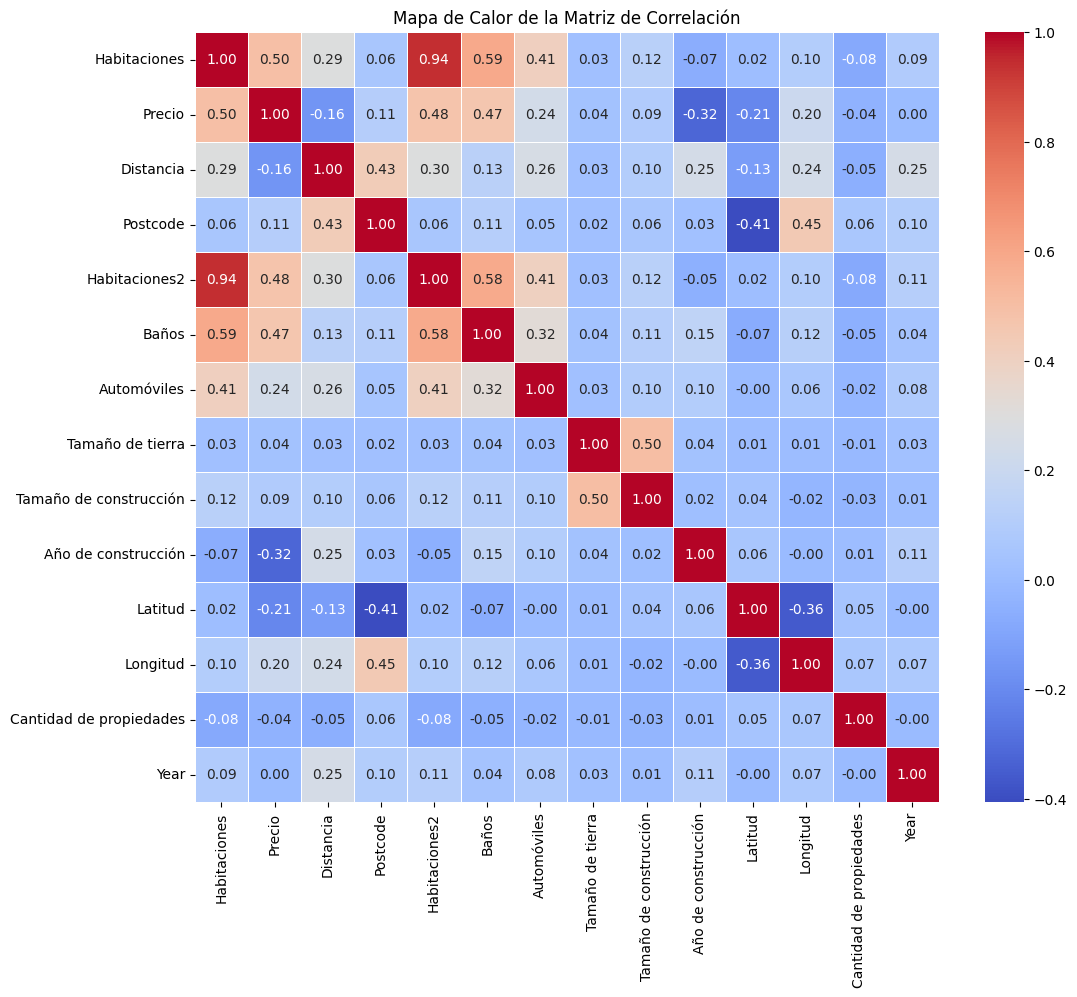

In [78]:
import seaborn as sns

plt.figure(figsize=(12, 10)) # Ajustar el tamaño para una mejor visualización
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

**10. De los datos a la definición de la hipótesis:**


### Evidencia A — `Precio`

Lo primero que observamos es que los precios tienen una dispersión importante. La mediana es de 903 mil, mientras que el promedio supera el millón. Esto indica que existen propiedades de precios muy altos que elevan el promedio. Por eso, no todas las propiedades pueden tratarse como si fueran iguales y necesitamos identificar qué características explican esas diferencias.

El precio medio de las propiedades es aproximadamente 1.076.000, mientras que la mediana es de 903.000. Además, existen propiedades desde 85.000 hasta 9.000.000.
Esto muestra que existe una gran diversidad de precios y algunos valores muy altos que empujan el promedio hacia arriba.


### Evidencia B — variables asociadas con `Precio`

Encontramos que el número de habitaciones entrega información relevante sobre el precio. Por ejemplo, una propiedad de una habitación tiene un precio mediano de 385 mil, mientras que una de cuatro habitaciones alcanza aproximadamente 1,285 millones. Esto nos muestra que las características físicas de la propiedad contienen información que potencialmente puede utilizar un modelo para estimar su precio.

La correlación entre Habitaciones y Precio es 0,497, una relación positiva moderada.

Pero incluso más fácil de explicar que la correlación son las medianas:
1. habitación → 385.000
2. habitaciones → 690.000
3. habitaciones → 950.000
4. habitaciones → 1.285.000
5. habitaciones → 1.660.000

Hasta las cinco habitaciones se observa un patrón bastante claro: a medida que aumenta la cantidad de habitaciones, también aumenta el precio típico.

También aparecen otras relaciones interesantes:

1. Habitaciones: 0,497 (fuerte)
2. Habitaciones2: 0,476 (fuerte)
3. Baños: 0,467 (fuerte)
4. Año de construcción: -0,324 (pobre)
5. Automóviles: 0,239 (regular)
6. Distancia: -0,163 (pobre)

Como se observa, no todas tienen la misma fuerza, pero en conjunto muestran que el precio no está completamente desconectado de las características disponibles, en cuanto al espacio físico de los inmuebles.

### Evidencia C — diferencias por tipo de propiedad

El tipo de propiedad también parece ser una variable importante. Las casas presentan un precio mediano de 1,08 millones, mientras que los duplex tienen una mediana de 560 mil. Esta diferencia considerable refuerza la idea de que las características de la propiedad permiten distinguir grupos con comportamientos de precios diferentes.

Las medianas de precio son:

1. Casa:	1.080.000
2. Casa pareada:	846.750
3. Duplex:	560.000

Una casa tiene prácticamente el doble del precio mediano de un duplex.

### Evidencia D — componente locacional

También encontramos una señal asociada a la ubicación. La distancia presenta una relación negativa con el precio, lo que sugiere que la localización podría aportar información al modelo. Sin embargo, la relación es relativamente débil, por lo que no sería suficiente utilizar únicamente esta variable.

- Correlación Distancia–Precio = -0,163.

Esto significa que, en términos generales, a mayor distancia, el precio tiende a disminuir, aunque la distancia por sí sola no explica mucho.

### Evidencia E — composición 2016 vs 2017

Cuando comparamos 2016 y 2017 encontramos señales de estabilidad, pero también diferencias. El precio mediano prácticamente no cambia, pasando de 900 mil a 910 mil, y se mantienen los mismos tipos de propiedad. Esto apoya la posibilidad de aprender patrones utilizando 2016. Sin embargo, en 2017 aumenta significativamente la cobertura geográfica y aparecen 172 barrios que no estaban presentes en 2016. Por eso no podemos asumir que **ambos años son exactamente iguales**. Esto es justamente lo que posteriormente tendremos que evaluar con el modelo.

Encontramos:
- Registros >>> 2016: 6.336	/ 2017: 7.244
- Precio mediano >>> 2016: 900.000	/ 2017: 910.000
- Distancia mediana	>>> 2016: 8,8	/ 2017: 10,5
- Barrios distintos >>> 2016:	142 / 2017:	313

La mediana del precio cambia solamente de 900.000 a 910.000, aproximadamente 1,1%.

Eso es una señal favorable: a nivel general, los precios típicos no parecen haber cambiado radicalmente.

Además, las mismas tres categorías de propiedad aparecen en ambos años. Tampoco aparecen nuevas categorías de método de venta.

Pero existen diferencias importantes en la composición:
1. Casas: 65,8% en 2016 → 72,9% en 2017.
2. Duplex: 25,7% → 19,1%.
3. Distancia mediana: 8,8 → 10,5.
4. Barrios: 142 → 313.

**Importante:** Hay 172 barrios presentes en 2017 que no aparecen en 2016. Esta evidencia juega en los dos sentidos y eso es precisamente crítico entre ambas datas.

**12. Conclusiones:**

Nuestro análisis muestra que el precio de las propiedades no se comporta de manera aleatoria. Encontramos diferencias claras según características como el número de habitaciones y el tipo de propiedad, además de señales relacionadas con la ubicación. Por ejemplo, las casas tienen un precio mediano de 1,08 millones frente a 560 mil de los duplex, y el precio también aumenta claramente con el número de habitaciones.

Al comparar los años, observamos además que el precio mediano se mantiene relativamente estable entre 2016 y 2017, pasando de 900 mil a 910 mil. Esto nos hace pensar que parte de los patrones de 2016 podría mantenerse en 2017. Sin embargo, también encontramos diferencias importantes, principalmente en la cobertura geográfica, ya que 2017 incorpora 172 barrios que no aparecen en 2016.

A partir de estas evidencias planteamos como hipótesis que las relaciones entre las características de las propiedades y su precio observadas en 2016 se mantienen suficientemente en 2017 como para construir un modelo predictivo que entregue mejores resultados que una estimación básica. La hipótesis nula plantea justamente lo contrario.

**13. Hipótesis:**


**- Hipótesis 1**

Las características de las propiedades observadas en 2016 —como cantidad de habitaciones, tipo de propiedad y ubicación— mantienen una relación suficientemente estable con el precio en 2017, por lo que es posible utilizar los datos de 2016 para predecir mejor los precios de 2017.

**- Hipótesis 0**

Las relaciones observadas entre las características de las propiedades y sus precios en 2016 no se mantienen suficientemente en 2017, por lo que utilizar los datos de 2016 no permitiría predecir los precios de 2017 mejor que una estimación básica.

**14. Limitaciones:**
- Existen valores faltantes que deben cuantificarse por variable.
- `BuildingArea` y `YearBuilt` requieren atención particular antes de imputar o transformar.
- Los outliers deben revisarse, no eliminarse por conveniencia gráfica.
- La composición de 2016 y 2017 puede diferir y debe comprobarse descriptivamente.
- La cobertura geográfica puede variar entre años.
- El dataset no contiene necesariamente todos los factores que influyen en el mercado inmobiliario.
- Asociación y correlación no implican causalidad.
- Si el rango de 2017 no cubre doce meses completos, ese año no debe describirse como un año calendario completo sin verificarlo.